In [1]:
import pandas as pd
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1

In [2]:


def manual_convolution2d(image, kernel):
    img_h, img_w = image.shape
    krn_h, krn_w = kernel.shape
    pad_h, pad_w = krn_h // 2, krn_w // 2
    
    padded_img = np.zeros((img_h + 2 * pad_h, img_w + 2 * pad_w), dtype=np.float32)
    padded_img[pad_h:pad_h + img_h, pad_w:pad_w + img_w] = image
    
    output = np.zeros_like(image, dtype=np.float32)
    
    for i in range(img_h):
        for j in range(img_w):
            val = 0.0
            for ki in range(krn_h):
                for kj in range(krn_w):
                    val += padded_img[i + ki, j + kj] * kernel[ki, kj]
            output[i, j] = val
            
    return output

img = cv2.imread('eye.jpg')

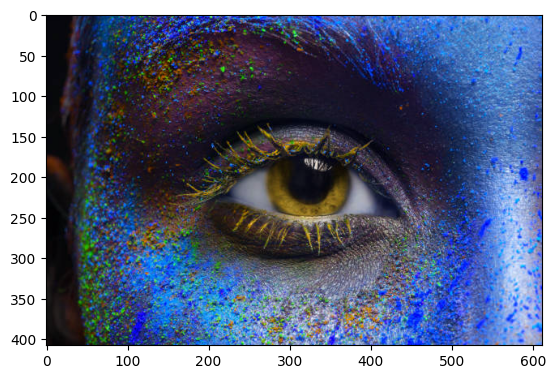

In [9]:
plt.imshow(img)

In [10]:
kernel_point = np.array([[-1,  0, -1],
                              [ 0,  4,  0],
                              [-1,  0, -1]], dtype=np.float32)
point = manual_convolution2d(img, kernel_point)
point = np.where(np.abs(point) > 100, 255, 0).astype(np.uint8)

ValueError: too many values to unpack (expected 2)